In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
# Load the breast cancer dataset
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data'

# Column names from dataset description
# For each feature, create a column for each statistic
column_names = ['id', 'diagnosis'] + [
    f'{feature}_{stat}' 
    for feature in ['radius', 'texture', 'perimeter', 'area', 'smoothness', 
                    'compactness', 'concavity', 'concave_points', 'symmetry', 'fractal_dimension']
    for stat in ['mean', 'se', 'worst']
]



In [4]:
print(len(column_names))
print(column_names)

32
['id', 'diagnosis', 'radius_mean', 'radius_se', 'radius_worst', 'texture_mean', 'texture_se', 'texture_worst', 'perimeter_mean', 'perimeter_se', 'perimeter_worst', 'area_mean', 'area_se', 'area_worst', 'smoothness_mean', 'smoothness_se', 'smoothness_worst', 'compactness_mean', 'compactness_se', 'compactness_worst', 'concavity_mean', 'concavity_se', 'concavity_worst', 'concave_points_mean', 'concave_points_se', 'concave_points_worst', 'symmetry_mean', 'symmetry_se', 'symmetry_worst', 'fractal_dimension_mean', 'fractal_dimension_se', 'fractal_dimension_worst']


In [5]:
cancer_data = pd.read_csv(url, names=column_names)

print(f"Dataset shape: {cancer_data.shape}")
print("\nFirst few rows:")
cancer_data.head()

Dataset shape: (569, 32)

First few rows:


,id,diagnosis,radius_mean,radius_se,radius_worst,texture_mean,texture_se,texture_worst,perimeter_mean,perimeter_se,...,concavity_worst,concave_points_mean,concave_points_se,concave_points_worst,symmetry_mean,symmetry_se,symmetry_worst,fractal_dimension_mean,fractal_dimension_se,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [7]:
# Dataset information
print("Dataset Info:")
print(cancer_data.info())


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   radius_se                569 non-null    float64
 4   radius_worst             569 non-null    float64
 5   texture_mean             569 non-null    float64
 6   texture_se               569 non-null    float64
 7   texture_worst            569 non-null    float64
 8   perimeter_mean           569 non-null    float64
 9   perimeter_se             569 non-null    float64
 10  perimeter_worst          569 non-null    float64
 11  area_mean                569 non-null    float64
 12  area_se                  569 non-null    float64
 13  area_worst               569 non-null    float64
 14  smoothness_mean        

In [10]:
print("\nMissing Values:")
print(cancer_data.isnull().sum().sum())



Missing Values:
0


In [12]:
print("\nTarget Distribution:")
print(cancer_data['diagnosis'].value_counts())


Target Distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64


In [13]:
print(f"\nMalignant (M): {(cancer_data['diagnosis'] == 'M').sum()} ({(cancer_data['diagnosis'] == 'M').sum()/len(cancer_data)*100:.2f}%)")
print(f"Benign (B): {(cancer_data['diagnosis'] == 'B').sum()} ({(cancer_data['diagnosis'] == 'B').sum()/len(cancer_data)*100:.2f}%)")


Malignant (M): 212 (37.26%)
Benign (B): 357 (62.74%)


In [14]:
# Statistical summary
print("Statistical Summary of Features:")
cancer_data.describe()

Statistical Summary of Features:


,id,radius_mean,radius_se,radius_worst,texture_mean,texture_se,texture_worst,perimeter_mean,perimeter_se,perimeter_worst,...,concavity_worst,concave_points_mean,concave_points_se,concave_points_worst,symmetry_mean,symmetry_se,symmetry_worst,fractal_dimension_mean,fractal_dimension_se,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


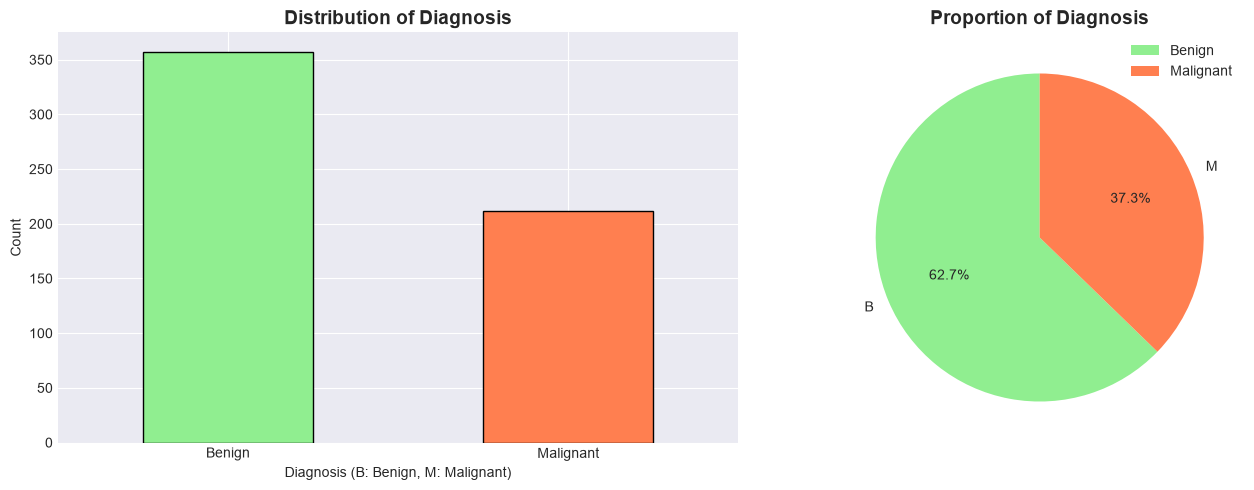

In [15]:
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
cancer_data['diagnosis'].value_counts().plot(kind='bar', ax=axes[0], 
                                              color=['lightgreen', 'coral'], edgecolor='black')
axes[0].set_title('Distribution of Diagnosis', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Diagnosis (B: Benign, M: Malignant)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Benign', 'Malignant'], rotation=0)

# Pie chart
cancer_data['diagnosis'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                             colors=['lightgreen', 'coral'], startangle=90)
axes[1].set_title('Proportion of Diagnosis', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')
axes[1].legend(['Benign', 'Malignant'])

plt.tight_layout()

In [17]:
# Separate features and target
X = cancer_data.drop(['id', 'diagnosis'], axis=1)
y = cancer_data['diagnosis'].map({'M': 1, 'B': 0})  # M=1 (Malignant), B=0 (Benign)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nNumber of features: {X.shape[1]}")

Features shape: (569, 30)
Target shape: (569,)

Number of features: 30


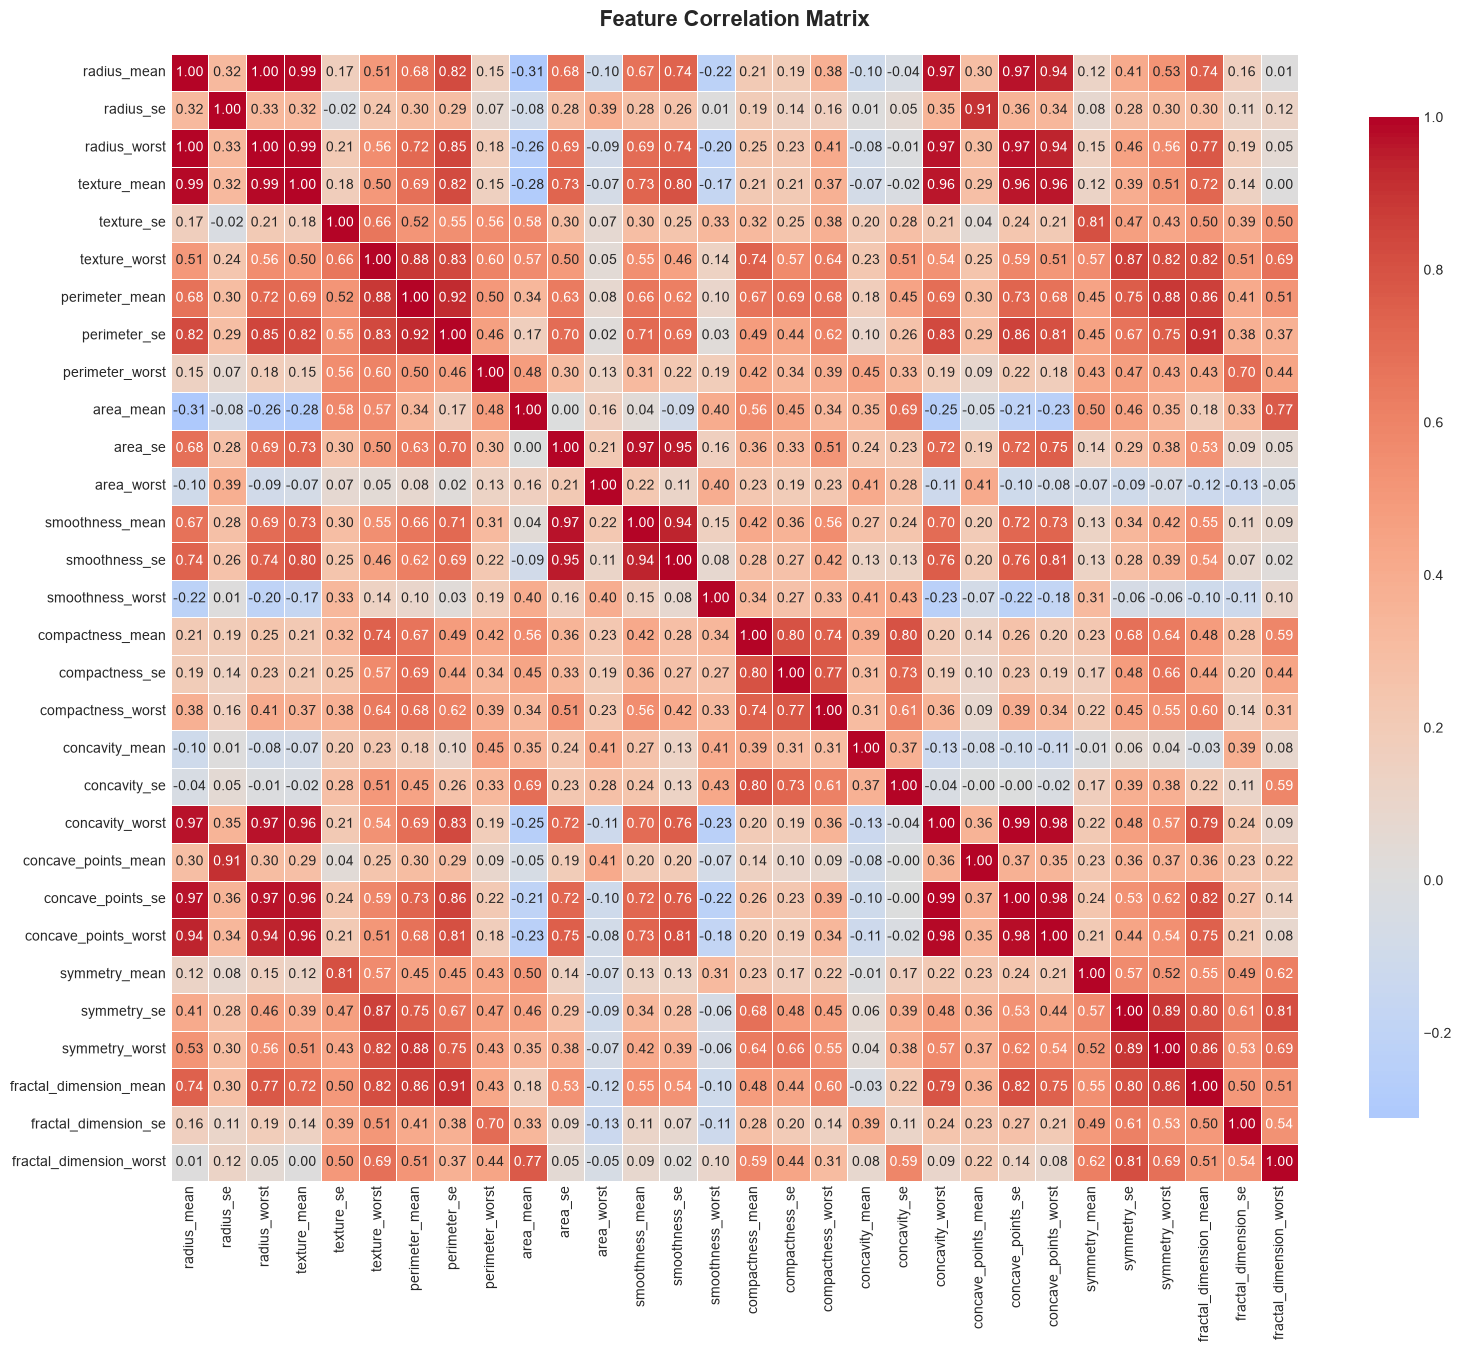

Notice: Many features are highly correlated - PCA will help reduce redundancy!


In [21]:
# Visualize correlations between features
plt.figure(figsize=(16, 14))
correlation_matrix = X.corr()
sns.heatmap(correlation_matrix, annot=True,fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("Notice: Many features are highly correlated - PCA will help reduce redundancy!")

In [22]:
# Feature scaling (CRITICAL for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easier handling
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Features standardized successfully!")
print(f"\nMean of scaled features (should be ~0):")
print(X_scaled_df.mean().head())
print(f"\nStd of scaled features (should be ~1):")
print(X_scaled_df.std().head())

Features standardized successfully!

Mean of scaled features (should be ~0):
radius_mean    -1.373633e-16
radius_se       6.868164e-17
radius_worst   -1.248757e-16
texture_mean   -2.185325e-16
texture_se     -8.366672e-16
dtype: float64

Std of scaled features (should be ~1):
radius_mean     1.00088
radius_se       1.00088
radius_worst    1.00088
texture_mean    1.00088
texture_se      1.00088
dtype: float64


In [23]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 455
Test set size: 114


In [24]:
# Fit PCA with all components to see explained variance
pca_full = PCA()
pca_full.fit(X_train)

# Get explained variance
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("Explained Variance by Each Component:")
for i, var in enumerate(explained_variance[:10]):
    print(f"PC{i+1}: {var:.4f} ({var*100:.2f}%)")
    
print(f"\nCumulative variance explained by first 10 components: {cumulative_variance[9]:.4f} ({cumulative_variance[9]*100:.2f}%)")

Explained Variance by Each Component:
PC1: 0.4518 (45.18%)
PC2: 0.1836 (18.36%)
PC3: 0.0956 (9.56%)
PC4: 0.0638 (6.38%)
PC5: 0.0561 (5.61%)
PC6: 0.0392 (3.92%)
PC7: 0.0223 (2.23%)
PC8: 0.0155 (1.55%)
PC9: 0.0128 (1.28%)
PC10: 0.0115 (1.15%)

Cumulative variance explained by first 10 components: 0.9523 (95.23%)


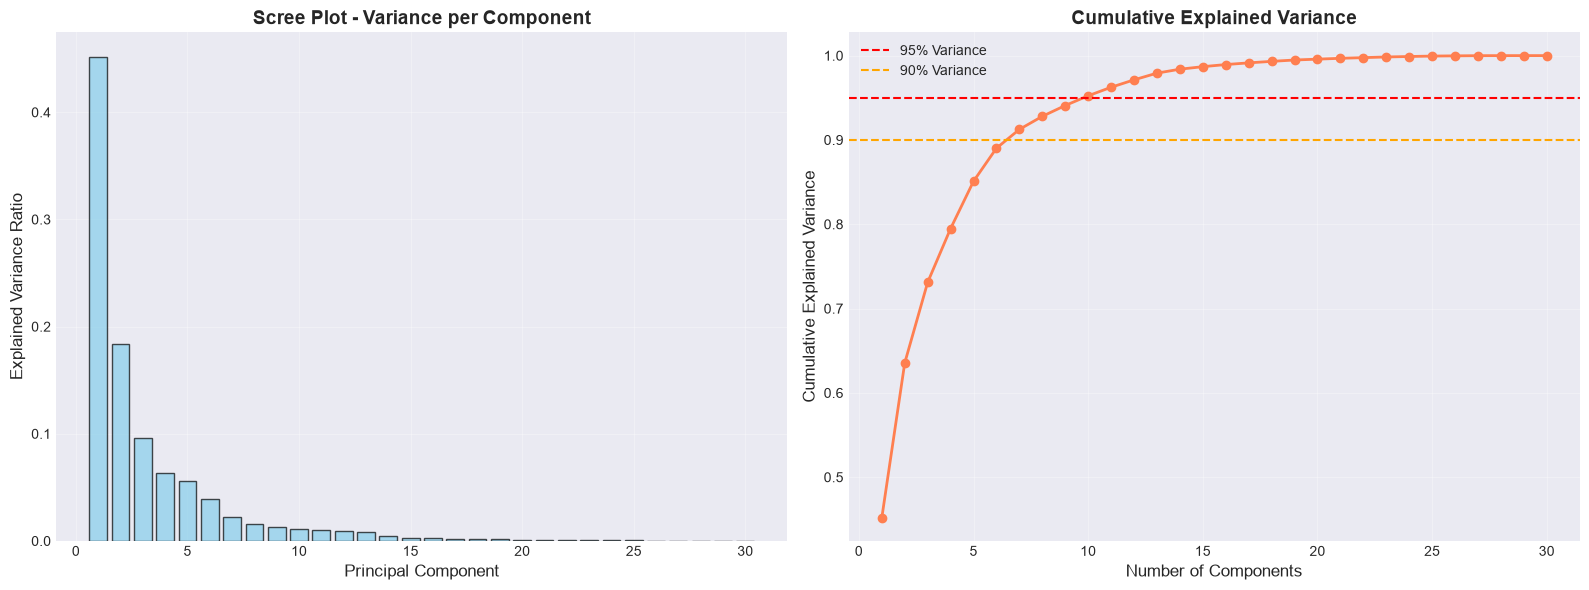

In [25]:
# Visualize explained variance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scree plot (individual variance)
axes[0].bar(range(1, len(explained_variance) + 1), explained_variance, 
           alpha=0.7, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Explained Variance Ratio', fontsize=12)
axes[0].set_title('Scree Plot - Variance per Component', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3)

# Cumulative variance plot
axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 
            marker='o', linestyle='-', linewidth=2, markersize=6, color='coral')
axes[1].axhline(y=0.95, color='red', linestyle='--', label='95% Variance')
axes[1].axhline(y=0.90, color='orange', linestyle='--', label='90% Variance')
axes[1].set_xlabel('Number of Components', fontsize=12)
axes[1].set_ylabel('Cumulative Explained Variance', fontsize=12)
axes[1].set_title('Cumulative Explained Variance', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()

In [26]:
# Find number of components for 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1

print(f"Number of components for 90% variance: {n_components_90}")
print(f"Number of components for 95% variance: {n_components_95}")
print(f"\nOriginal number of features: {X.shape[1]}")
print(f"Dimensionality reduction: {X.shape[1]} → {n_components_95} (95% variance retained)")
print(f"Reduction percentage: {(1 - n_components_95/X.shape[1])*100:.2f}%")

Number of components for 90% variance: 7
Number of components for 95% variance: 10

Original number of features: 30
Dimensionality reduction: 30 → 10 (95% variance retained)
Reduction percentage: 66.67%


In [27]:
# Apply PCA with 2 components for visualization
pca_2d = PCA(n_components=2, random_state=42)
X_train_pca_2d = pca_2d.fit_transform(X_train)
X_test_pca_2d = pca_2d.transform(X_test)

print(f"2D PCA shape: {X_train_pca_2d.shape}")
print(f"Explained variance (2 components): {pca_2d.explained_variance_ratio_.sum():.4f}")
print(f"PC1 variance: {pca_2d.explained_variance_ratio_[0]:.4f}")
print(f"PC2 variance: {pca_2d.explained_variance_ratio_[1]:.4f}")

2D PCA shape: (455, 2)
Explained variance (2 components): 0.6355
PC1 variance: 0.4518
PC2 variance: 0.1836


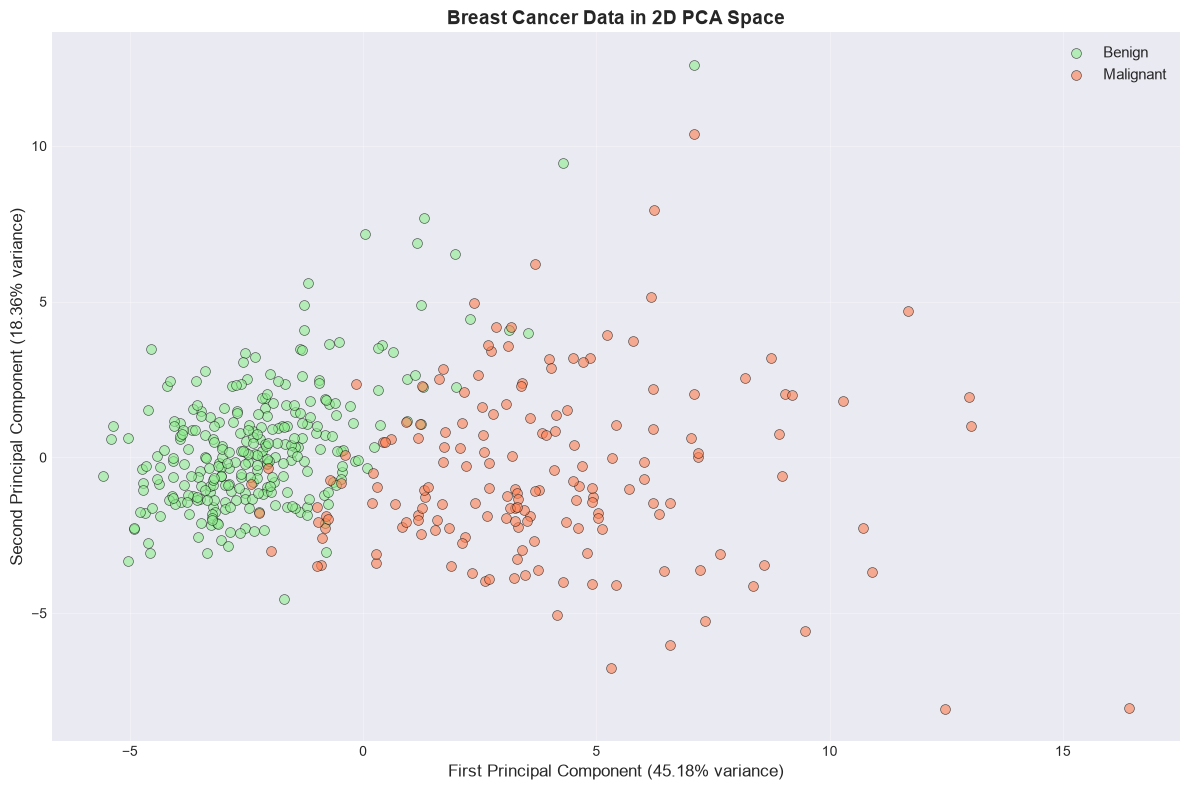

In [28]:
# Visualize data in 2D PCA space
plt.figure(figsize=(12, 8))

# Separate classes
benign_mask = y_train == 0
malignant_mask = y_train == 1

plt.scatter(X_train_pca_2d[benign_mask, 0], X_train_pca_2d[benign_mask, 1], 
           c='lightgreen', label='Benign', alpha=0.6, s=50, edgecolor='black', linewidth=0.5)
plt.scatter(X_train_pca_2d[malignant_mask, 0], X_train_pca_2d[malignant_mask, 1], 
           c='coral', label='Malignant', alpha=0.6, s=50, edgecolor='black', linewidth=0.5)

plt.xlabel(f'First Principal Component ({pca_2d.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
plt.ylabel(f'Second Principal Component ({pca_2d.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
plt.title('Breast Cancer Data in 2D PCA Space', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()

In [29]:
# Apply PCA with 3 components
pca_3d = PCA(n_components=3, random_state=42)
X_train_pca_3d = pca_3d.fit_transform(X_train)
X_test_pca_3d = pca_3d.transform(X_test)

print(f"3D PCA shape: {X_train_pca_3d.shape}")
print(f"Explained variance (3 components): {pca_3d.explained_variance_ratio_.sum():.4f}")
print(f"PC1: {pca_3d.explained_variance_ratio_[0]:.4f}")
print(f"PC2: {pca_3d.explained_variance_ratio_[1]:.4f}")
print(f"PC3: {pca_3d.explained_variance_ratio_[2]:.4f}")

3D PCA shape: (455, 3)
Explained variance (3 components): 0.7311
PC1: 0.4518
PC2: 0.1836
PC3: 0.0956


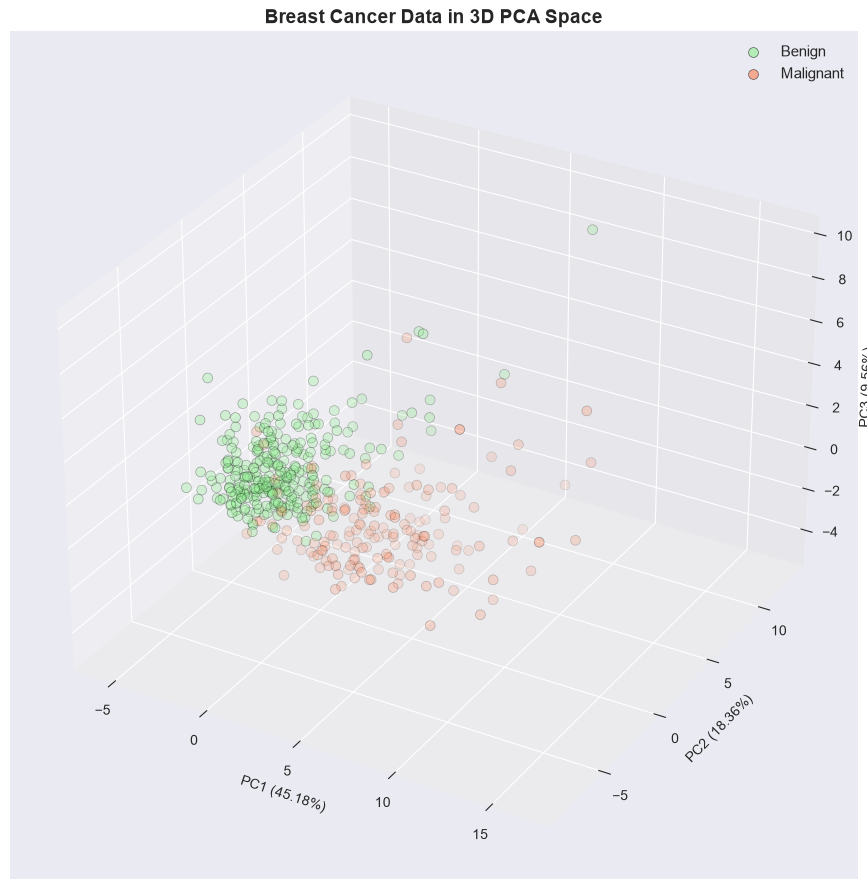

In [30]:
# 3D scatter plot
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_train_pca_3d[benign_mask, 0], 
          X_train_pca_3d[benign_mask, 1], 
          X_train_pca_3d[benign_mask, 2],
          c='lightgreen', label='Benign', alpha=0.6, s=50, edgecolor='black', linewidth=0.5)

ax.scatter(X_train_pca_3d[malignant_mask, 0], 
          X_train_pca_3d[malignant_mask, 1], 
          X_train_pca_3d[malignant_mask, 2],
          c='coral', label='Malignant', alpha=0.6, s=50, edgecolor='black', linewidth=0.5)

ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.2%})', fontsize=10)
ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.2%})', fontsize=10)
ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.2%})', fontsize=10)
ax.set_title('Breast Cancer Data in 3D PCA Space', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()

In [31]:
# Get component loadings (contribution of each feature to PCs)
loadings = pd.DataFrame(
    pca_3d.components_.T,
    columns=['PC1', 'PC2', 'PC3'],
    index=X.columns
)

print("Top features contributing to Principal Components:")
print("\nPC1 - Top 5 features:")
print(loadings['PC1'].abs().sort_values(ascending=False).head())
print("\nPC2 - Top 5 features:")
print(loadings['PC2'].abs().sort_values(ascending=False).head())
print("\nPC3 - Top 5 features:")
print(loadings['PC3'].abs().sort_values(ascending=False).head())

Top features contributing to Principal Components:

PC1 - Top 5 features:
perimeter_se              0.260943
perimeter_mean            0.258139
fractal_dimension_mean    0.247739
texture_worst             0.240434
concave_points_se         0.235747
Name: PC1, dtype: float64

PC2 - Top 5 features:
area_mean                  0.358684
fractal_dimension_worst    0.282119
concavity_se               0.270196
texture_mean               0.236793
radius_mean                0.236651
Name: PC2, dtype: float64

PC3 - Top 5 features:
area_worst          0.356224
concavity_mean      0.297411
symmetry_mean       0.279461
smoothness_worst    0.274173
smoothness_mean     0.266693
Name: PC3, dtype: float64


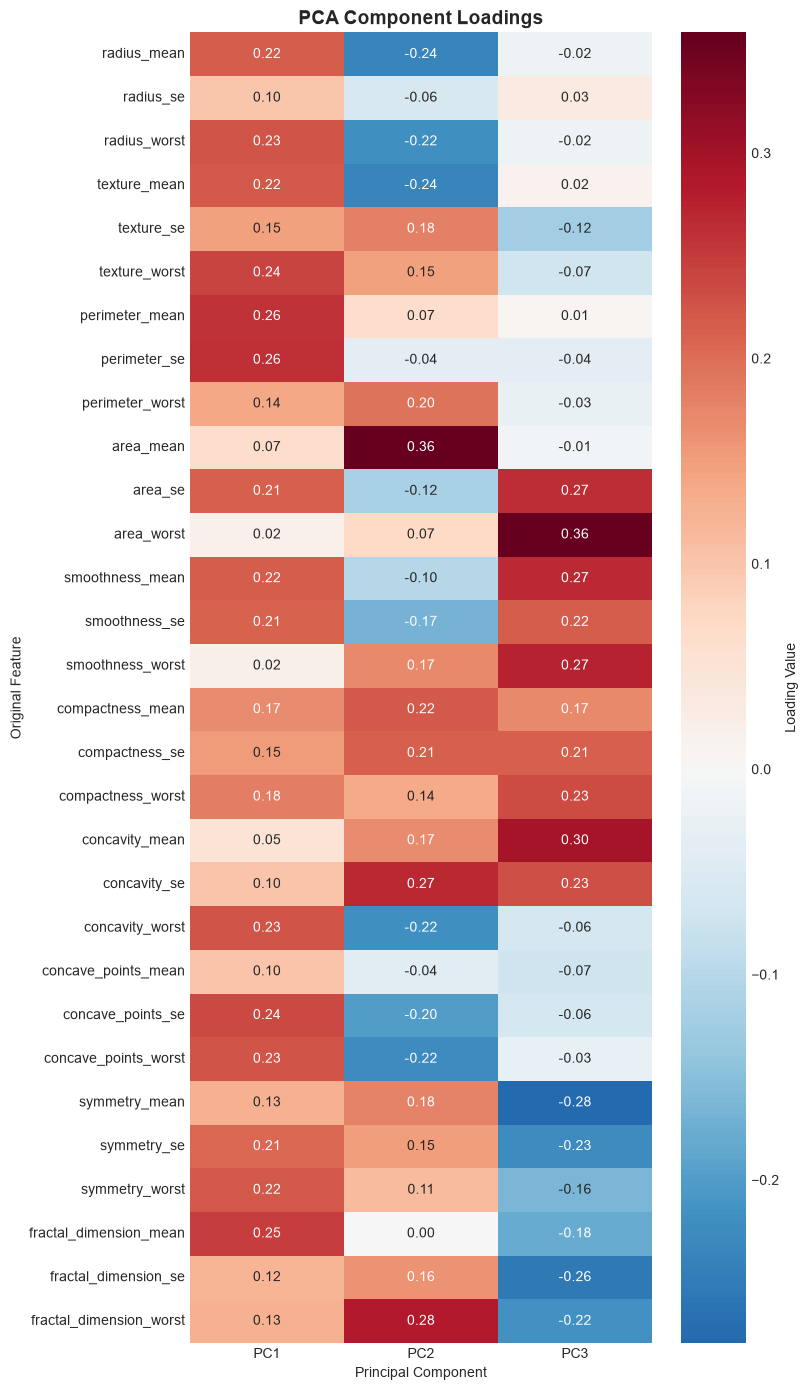

In [32]:
# Visualize loadings as heatmap
plt.figure(figsize=(8, 14))
sns.heatmap(loadings, cmap='RdBu_r', center=0, annot=True, fmt='.2f', 
            cbar_kws={'label': 'Loading Value'})
plt.title('PCA Component Loadings', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component')
plt.ylabel('Original Feature')
plt.tight_layout()

In [33]:
# Train on original features
lr_original = LogisticRegression(max_iter=10000, random_state=42)
lr_original.fit(X_train, y_train)

y_pred_original = lr_original.predict(X_test)
acc_original = accuracy_score(y_test, y_pred_original)

print("Logistic Regression - Original Features (30 features):")
print(f"Accuracy: {acc_original:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_original, target_names=['Benign', 'Malignant']))

Logistic Regression - Original Features (30 features):
Accuracy: 0.9649

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [34]:
# Apply PCA with components for 95% variance
pca_optimal = PCA(n_components=n_components_95, random_state=42)
X_train_pca = pca_optimal.fit_transform(X_train)
X_test_pca = pca_optimal.transform(X_test)

# Train on PCA features
lr_pca = LogisticRegression(max_iter=10000, random_state=42)
lr_pca.fit(X_train_pca, y_train)

y_pred_pca = lr_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test, y_pred_pca)

print(f"Logistic Regression - PCA Features ({n_components_95} features):")
print(f"Accuracy: {acc_pca:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_pca, target_names=['Benign', 'Malignant']))

Logistic Regression - PCA Features (10 features):
Accuracy: 0.9825

Classification Report:
              precision    recall  f1-score   support

      Benign       0.97      1.00      0.99        72
   Malignant       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [35]:
# Random Forest on original features
rf_original = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_original.fit(X_train, y_train)
y_pred_rf_original = rf_original.predict(X_test)
acc_rf_original = accuracy_score(y_test, y_pred_rf_original)

# Random Forest on PCA features
rf_pca = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_pca.fit(X_train_pca, y_train)
y_pred_rf_pca = rf_pca.predict(X_test_pca)
acc_rf_pca = accuracy_score(y_test, y_pred_rf_pca)

print("Random Forest - Original Features:")
print(f"Accuracy: {acc_rf_original:.4f}")
print(f"\nRandom Forest - PCA Features ({n_components_95} components):")
print(f"Accuracy: {acc_rf_pca:.4f}")

Random Forest - Original Features:
Accuracy: 0.9737

Random Forest - PCA Features (10 components):
Accuracy: 0.9386


In [36]:
# Comparison table
comparison_data = {
    'Model': [
        'Logistic Regression (Original)',
        f'Logistic Regression (PCA-{n_components_95})',
        'Random Forest (Original)',
        f'Random Forest (PCA-{n_components_95})'
    ],
    'Features': [30, n_components_95, 30, n_components_95],
    'Accuracy': [acc_original, acc_pca, acc_rf_original, acc_rf_pca]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*70)
print("MODEL PERFORMANCE COMPARISON")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)


MODEL PERFORMANCE COMPARISON
                         Model  Features  Accuracy
Logistic Regression (Original)        30  0.964912
  Logistic Regression (PCA-10)        10  0.982456
      Random Forest (Original)        30  0.973684
        Random Forest (PCA-10)        10  0.938596


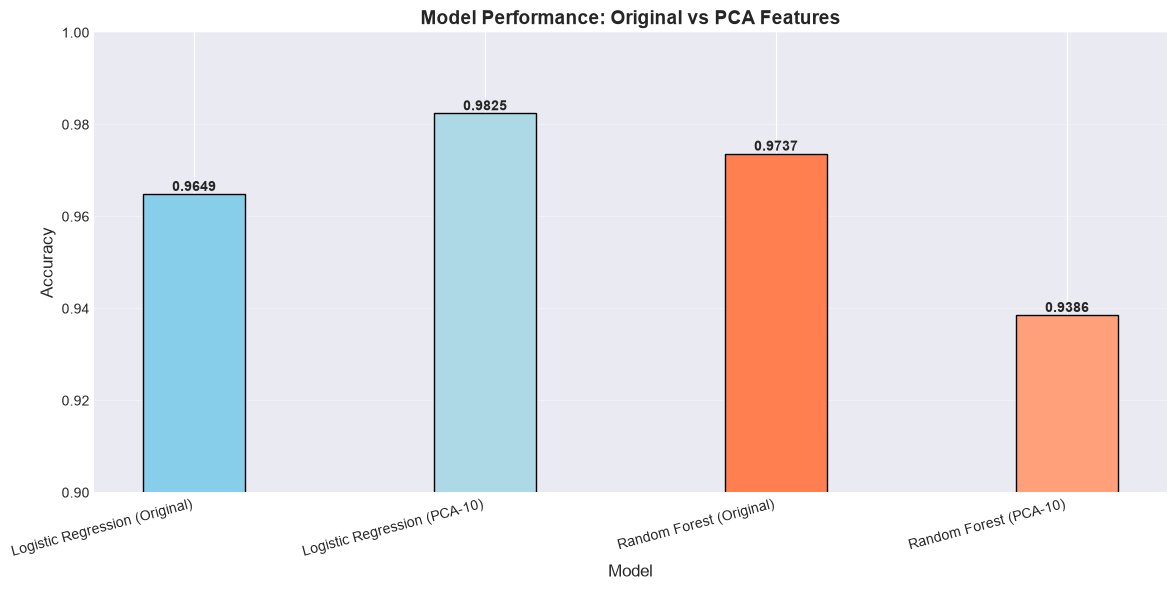

In [37]:
# Visualize comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_df))
width = 0.35

bars = ax.bar(x, comparison_df['Accuracy'], width, 
              color=['skyblue', 'lightblue', 'coral', 'lightsalmon'],
              edgecolor='black')

# Add value labels on bars
for i, (bar, acc) in enumerate(zip(bars, comparison_df['Accuracy'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{acc:.4f}',
           ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Model Performance: Original vs PCA Features', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=15, ha='right')
ax.set_ylim([0.9, 1.0])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

In [38]:
# Test different numbers of components
n_components_range = range(2, 31, 2)
accuracies = []
variances = []

for n in n_components_range:
    # Apply PCA
    pca_temp = PCA(n_components=n, random_state=42)
    X_train_temp = pca_temp.fit_transform(X_train)
    X_test_temp = pca_temp.transform(X_test)
    
    # Train model
    lr_temp = LogisticRegression(max_iter=10000, random_state=42)
    lr_temp.fit(X_train_temp, y_train)
    
    # Evaluate
    y_pred_temp = lr_temp.predict(X_test_temp)
    acc = accuracy_score(y_test, y_pred_temp)
    var = pca_temp.explained_variance_ratio_.sum()
    
    accuracies.append(acc)
    variances.append(var)
    
    print(f"n={n:2d}: Accuracy={acc:.4f}, Variance Explained={var:.4f}")

n= 2: Accuracy=0.9386, Variance Explained=0.6355
n= 4: Accuracy=0.9649, Variance Explained=0.7949
n= 6: Accuracy=0.9737, Variance Explained=0.8902
n= 8: Accuracy=0.9912, Variance Explained=0.9280
n=10: Accuracy=0.9825, Variance Explained=0.9523
n=12: Accuracy=0.9912, Variance Explained=0.9712
n=14: Accuracy=0.9825, Variance Explained=0.9839
n=16: Accuracy=0.9825, Variance Explained=0.9894
n=18: Accuracy=0.9825, Variance Explained=0.9932
n=20: Accuracy=0.9737, Variance Explained=0.9958
n=22: Accuracy=0.9737, Variance Explained=0.9976
n=24: Accuracy=0.9737, Variance Explained=0.9989
n=26: Accuracy=0.9737, Variance Explained=0.9997
n=28: Accuracy=0.9737, Variance Explained=1.0000
n=30: Accuracy=0.9737, Variance Explained=1.0000


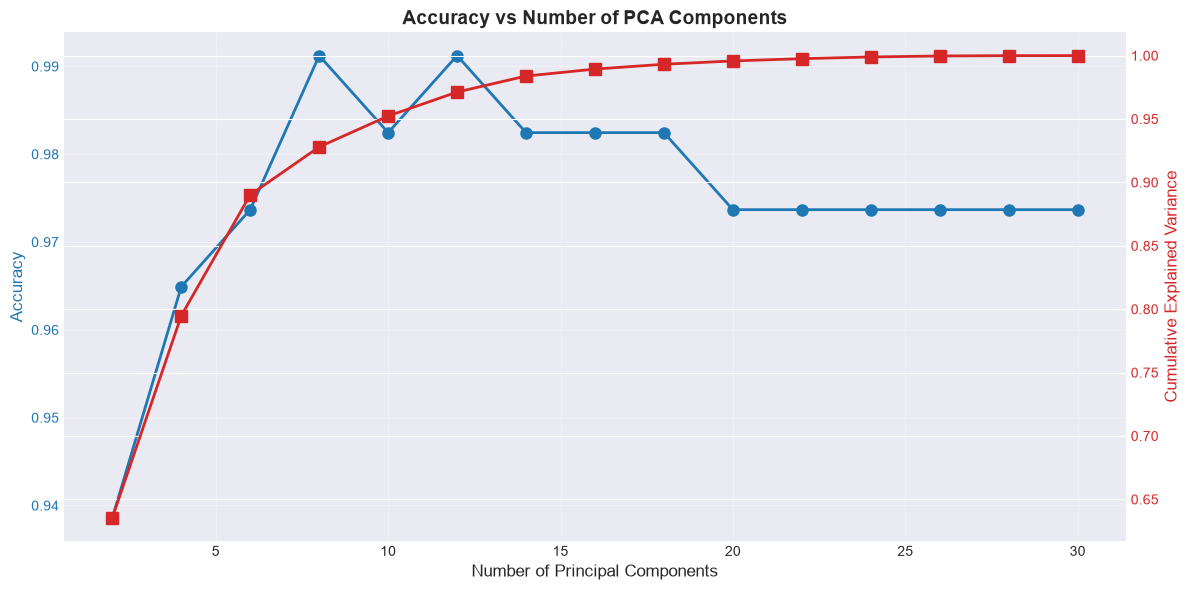

In [39]:
# Plot the relationship
fig, ax1 = plt.subplots(figsize=(12, 6))

color1 = 'tab:blue'
ax1.set_xlabel('Number of Principal Components', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12, color=color1)
ax1.plot(n_components_range, accuracies, marker='o', color=color1, 
         linewidth=2, markersize=8, label='Accuracy')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('Cumulative Explained Variance', fontsize=12, color=color2)
ax2.plot(n_components_range, variances, marker='s', color=color2, 
         linewidth=2, markersize=8, label='Variance')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Accuracy vs Number of PCA Components', fontsize=14, fontweight='bold')
fig.tight_layout()

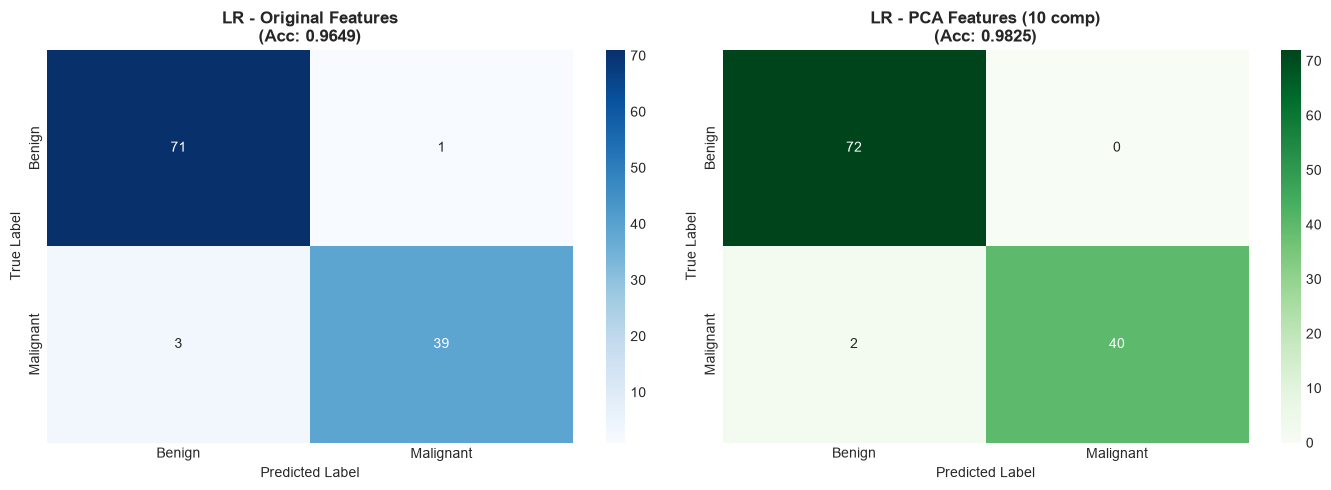

In [40]:
# Compare confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original features
cm_original = confusion_matrix(y_test, y_pred_original)
sns.heatmap(cm_original, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
axes[0].set_title(f'LR - Original Features\n(Acc: {acc_original:.4f})', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# PCA features
cm_pca = confusion_matrix(y_test, y_pred_pca)
sns.heatmap(cm_pca, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
axes[1].set_title(f'LR - PCA Features ({n_components_95} comp)\n(Acc: {acc_pca:.4f})', fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()